# Same-day flood models — results (3D-CNN vs ConvLSTM)

Run this **after** training the models with `cnn3d_arthur_train.py` and/or
`convlstm_arthur_train.py`. It:
1. compares the training curves (loss + test PR-AUC) of both models,
2. reloads each saved checkpoint and predicts on the 5 test days,
3. maps **ground truth | 3D-CNN | ConvLSTM** side by side for every test day.

Each model's class/dataset/settings come straight from its training script — no
duplication. Needs both models trained (their `*.pt` + `*_results.npz` exist).

## 0 · Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import geopandas as gpd
from torch.utils.data import DataLoader
from sklearn.metrics import average_precision_score

# locate repo root + the training scripts' directory, then import from them
SIG_ROOT = Path.cwd()
while not (SIG_ROOT / 'siggrid.py').exists() and SIG_ROOT != SIG_ROOT.parent:
    SIG_ROOT = SIG_ROOT.parent
sys.path.insert(0, str(SIG_ROOT))
sys.path.insert(0, str(SIG_ROOT / 'notebooks'))

from siggrid import build_grid_cells, STATES_GEOJSON
import cnn3d_arthur_train as cnn3d
import convlstm_arthur_train as convlstm

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
NB = SIG_ROOT / 'notebooks'
CACHE_DIR = cnn3d.CACHE_DIR
BANDS = cnn3d.BANDS
band_idx = np.array([b - 1 for b in BANDS])

# the two models to compare: label -> (module, class, checkpoint, results npz)
MODELS = {
    '3D-CNN':   dict(module=cnn3d,    cls='GOES3DCNN',    ckpt='cnn3d_arthur.pt',    results='cnn3d_results.npz'),
    'ConvLSTM': dict(module=convlstm, cls='GOESConvLSTM', ckpt='convlstm_arthur.pt', results='convlstm_results.npz'),
}

# shared grid / land mask / test days / base rate, loaded once
cells, gr, gc, land = build_grid_cells()
_tr, _va, te_days = cnn3d.load_splits()
base = float(np.mean([np.load(CACHE_DIR / f'{d}_y.npy')[land].mean() for d in te_days]))

# grid polygons + state outlines in Albers (EPSG:5070) for the maps
cells_albers = cells.to_crs(5070)
RR, CC = cells_albers['R'].to_numpy(), cells_albers['C'].to_numpy()
states = gpd.read_file(STATES_GEOJSON)
states = states[~states['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])].to_crs(5070)

print('device:', DEVICE, '| test days:', len(te_days), '| base rate:', round(base, 4))
for name, m in MODELS.items():
    print(f"  {name:9s} checkpoint={(NB / m['ckpt']).exists()}  results={(CACHE_DIR / m['results']).exists()}")

device: cuda:0 | test days: 5 | base rate: 0.0274
  3D-CNN    checkpoint=True  results=True
  ConvLSTM  checkpoint=True  results=True


In [2]:
# helpers used by every section below
THRESHOLD = 0.9     # probabilities >= THRESHOLD are shown as predicted-flood (binary)
N_SHOW = 2          # how many random test days to show in the comparison plot
SAMPLE_SEED = 10     # seed for picking which days (set to None for a fresh draw each run)
# distinct color per column (matches the training-curve colors)
COLORS = {'Ground truth': 'Greens', '3D-CNN': 'Blues', 'ConvLSTM': 'Oranges'}

def load_history(results):
    path = CACHE_DIR / results
    if not path.exists():
        return None
    h = np.load(path)['hist']
    return h if (h.ndim == 2 and h.shape[1] == 4) else None   # cols: epoch, lr, loss, prauc

def run_inference(name):
    """Load the checkpoint and predict on the test days -> (probs, trues, per_day_prauc)."""
    m = MODELS[name]
    model = getattr(m['module'], m['cls'])(n_bands=len(BANDS)).to(DEVICE)
    model.load_state_dict(torch.load(NB / m['ckpt'], map_location=DEVICE))
    model.eval()
    probs, trues = [], []
    loader = DataLoader(m['module'].SameDayCache(te_days, band_idx), batch_size=1, num_workers=2)
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE).float()
            with torch.autocast('cuda', dtype=torch.bfloat16):
                p = torch.sigmoid(model(x)).float().squeeze(1).cpu()
            probs.append(p.numpy()[0]); trues.append(y.numpy()[0])
    probs, trues = np.array(probs), np.array(trues)
    per_day = [average_precision_score(trues[i][land].ravel(), probs[i][land].ravel())
               for i in range(len(te_days))]
    return probs, trues, per_day

def _draw(ax, values, cmap, title=None, ylabel=None, sub=None):
    """Draw one binary 0/1 cell map on ax (states outline + colored cells, no chrome)."""
    gdf = cells_albers.copy()
    gdf['v'] = values[RR, CC]
    gdf.boundary.plot(ax=ax, color='white', lw=0.1, zorder=2)
    gdf.plot(column='v', cmap=cmap, vmin=0, vmax=1, ax=ax, zorder=1, edgecolor='none')
    states.boundary.plot(ax=ax, color='0.55', lw=0.5, zorder=3)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold', labelpad=10)
    if sub:
        ax.set_xlabel(sub, fontsize=10, color='0.3')

def show_comparison(results, models=('3D-CNN', 'ConvLSTM')):
    """3-column grid (Ground truth | model_1 | model_2) for N_SHOW random test days.

    Predictions are binarized at THRESHOLD; each column has its own color; the
    column subtitle keeps each day's (threshold-free) PR-AUC."""
    trues = results[models[0]][1]
    headers = ['Ground truth', *models]
    rng = np.random.default_rng(SAMPLE_SEED)
    sel = sorted(rng.choice(len(te_days), size=min(N_SHOW, len(te_days)), replace=False))
    n, ncol = len(sel), 1 + len(models)
    fig, axes = plt.subplots(n, ncol, figsize=(4.4 * ncol, 3.1 * n))
    if n == 1:
        axes = axes[None, :]
    for r, i in enumerate(sel):
        _draw(axes[r, 0], trues[i], COLORS['Ground truth'],
              title=headers[0] if r == 0 else None, ylabel=te_days[i])
        for j, mname in enumerate(models, start=1):
            probs, _, per_day = results[mname]
            _draw(axes[r, j], (probs[i] >= THRESHOLD).astype(float), COLORS[mname],
                  title=headers[j] if r == 0 else None, sub=f'PR-AUC {per_day[i]:.3f}')
    fig.suptitle(f'Ground truth vs predictions  (binary @ p ≥ {THRESHOLD:g})',
                 fontsize=15, fontweight='bold', y=1.005)
    plt.tight_layout()
    plt.show()

## 1 · Training curves — both models

Train loss (left) and test PR-AUC (right) for every model that has a `*_results.npz`.

3D-CNN: best test PR-AUC 0.3285 @ epoch 13  (12.0x the random baseline of 0.0274)
ConvLSTM: best test PR-AUC 0.3154 @ epoch 17  (11.5x the random baseline of 0.0274)


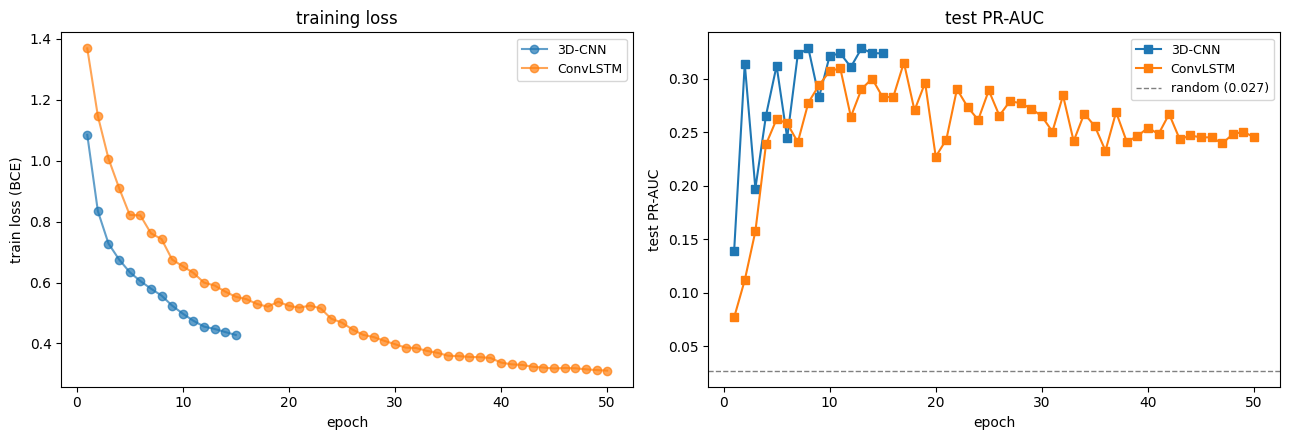

In [3]:
colors = {'3D-CNN': 'tab:blue', 'ConvLSTM': 'tab:orange'}
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.5))
for name, m in MODELS.items():
    h = load_history(m['results'])
    if h is None:
        print(f'{name}: no results npz yet — train it first'); continue
    ep, lr, loss, prauc = h[:, 0], h[:, 1], h[:, 2], h[:, 3]
    a0.plot(ep, loss, 'o-', color=colors[name], label=name, alpha=0.7)
    a1.plot(ep, prauc, 's-', color=colors[name], label=name)
    print(f'{name}: best test PR-AUC {prauc.max():.4f} @ epoch {int(ep[prauc.argmax()])}  '
          f'({prauc.max() / base:.1f}x the random baseline of {base:.4f})')

a0.set_xlabel('epoch'); a0.set_ylabel('train loss (BCE)'); a0.set_title('training loss')
a0.legend(fontsize=9)
a1.axhline(base, ls='--', color='gray', lw=1, label=f'random ({base:.3f})')
a1.set_xlabel('epoch'); a1.set_ylabel('test PR-AUC'); a1.set_title('test PR-AUC')
a1.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 2 · Ground truth vs predictions — 3D-CNN & ConvLSTM

`N_SHOW` random test days (set in the helpers cell), three columns:
**ground truth | 3D-CNN | ConvLSTM** — binary flood at `p ≥ THRESHOLD`, each column
in its own color. Per-day PR-AUC is shown under each model's map.

day       3D-CNN      ConvLSTM    warned cells
----------------------------------------------
20260603  0.167       0.190       50
20260611  0.380       0.469       90
20260614  0.192       0.068       96
20260619  0.410       0.292       115
20260621  0.383       0.287       110
----------------------------------------------
mean      0.306       0.261       


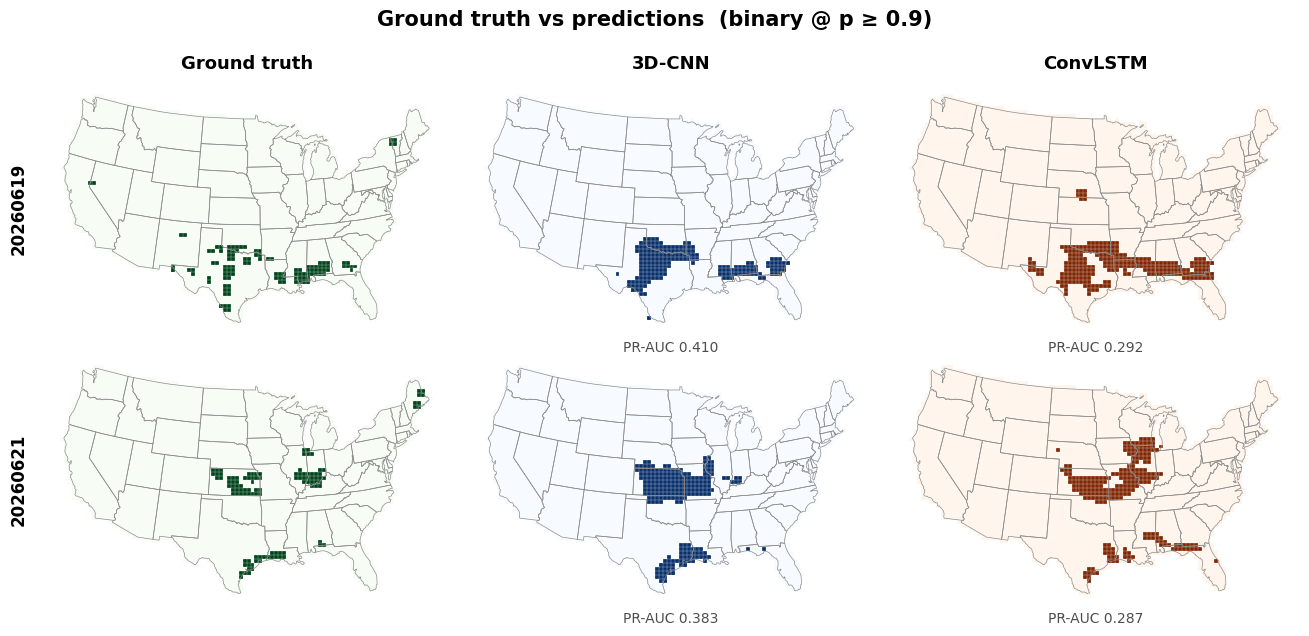

In [4]:
# run inference for both models, then plot the 3-column comparison
results = {name: run_inference(name) for name in MODELS}

# per-day PR-AUC summary
hdr = 'day'.ljust(10) + ''.join(n.ljust(12) for n in MODELS) + 'warned cells'
print(hdr); print('-' * len(hdr))
for i, d in enumerate(te_days):
    row = d.ljust(10) + ''.join(f'{results[n][2][i]:.3f}'.ljust(12) for n in MODELS)
    print(row + str(int(results[list(MODELS)[0]][1][i][land].sum())))
print('-' * len(hdr))
print('mean'.ljust(10) + ''.join(f'{np.mean(results[n][2]):.3f}'.ljust(12) for n in MODELS))

show_comparison(results)